# Simple Linear Regression: Predict House Price from Area

This notebook demonstrates a simple linear regression model that predicts house price using the house area. It follows the required structure: Problem Statement, Understanding of Dataset, Theory, Math, Diagram, Pseudocode, Expected/Obtained output, and implements data cleaning, EDA, feature scaling, feature engineering, and evaluation metrics. The notebook generates a synthetic CSV sample (`houses.csv`) and reads it as input so it behaves like an exam where a CSV will be provided.

Note: If you receive a different CSV in the exam, change the `DATA_PATH`, `FEATURE_COL`, and `TARGET_COL` variables accordingly (see the first code cell comments).

In [1]:
# Cell 2: Imports and sample CSV generation
# Change DATA_PATH, FEATURE_COL, TARGET_COL if a different CSV is provided in exam
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

# Constants - change these if the exam CSV uses different column names
DATA_PATH = "houses.csv"  # expected CSV filename
FEATURE_COL = "area"      # input feature column name
TARGET_COL = "price"      # target column name

# Create a simple synthetic dataset and save to CSV if it doesn't exist
if not os.path.exists(DATA_PATH):
    np.random.seed(42)
    n = 200
    areas = np.random.randint(500, 3500, size=n)  # area in sq.ft
    # Linear relation: price = 50 * area + 20000 + noise
    prices = 50 * areas + 20000 + np.random.normal(0, 20000, size=n)
    df_sample = pd.DataFrame({FEATURE_COL: areas, TARGET_COL: prices})
    df_sample.to_csv(DATA_PATH, index=False)
    print(f"Sample CSV created at {DATA_PATH} with {n} rows")
else:
    print(f"Found existing {DATA_PATH}, will use it")

# Quick check - print first rows
print(pd.read_csv(DATA_PATH).head())

Found existing houses.csv, will use it
   area          price
0  1360   49624.575694
1  1794  109169.722491
2  1630  102704.604199
3  1595  149014.842250
4  2138  123052.780704


## Understanding of Dataset

Load the CSV, show first rows, shape, column names, dtypes and a basic statistical summary. The target variable is `price` and the input is `area` (sq.ft). If the exam CSV uses different names, update `FEATURE_COL` and `TARGET_COL` in the imports cell.

In [2]:
# Cell 3: Load CSV and show basic info
df = pd.read_csv(DATA_PATH)

# Show first 8 rows
print('First rows:')
print(df.head(8))

# Shape and columns
print('\nDataset shape:', df.shape)
print('\nColumns:', list(df.columns))
print('\nData types:')
print(df.dtypes)

# Statistical summary
print('\nSummary statistics:')
print(df.describe().T)

# Confirm which columns are being used
print(f"\nUsing feature column: {FEATURE_COL}, target column: {TARGET_COL}")

First rows:
   area          price
0  1360   49624.575694
1  1794  109169.722491
2  1630  102704.604199
3  1595  149014.842250
4  2138  123052.780704
5  2669  159480.946847
6   966   67605.764606
7  1738   83526.439248

Dataset shape: (200, 2)

Columns: ['area', 'price']

Data types:
area       int64
price    float64
dtype: object

Summary statistics:
       count           mean           std           min           25%  \
area   200.0    2064.925000    819.162374    521.000000   1435.750000   
price  200.0  124277.287038  44125.247273  27661.515315  87089.187112   

                 50%            75%           max  
area     2017.500000    2767.500000    3477.00000  
price  126037.290806  159578.294216  234393.12394  

Using feature column: area, target column: price


## Data Cleaning

Check for missing values, duplicates and invalid values (like negative area or price). Perform simple fixes and document decisions in comments.

In [3]:
# Cell 4: Data cleaning steps
# 1) Missing values
print('Missing values:')
print(df.isnull().sum())

# 2) Duplicates
dupes = df.duplicated().sum()
print(f"\nDuplicate rows: {dupes}")
if dupes > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print('Dropped duplicates')

# 3) Invalid values - negative or zero areas/prices
invalid_area = (df[FEATURE_COL] <= 0).sum()
invalid_price = (df[TARGET_COL] <= 0).sum()
print(f"\nInvalid area rows (<=0): {invalid_area}")
print(f"Invalid price rows (<=0): {invalid_price}")

# Remove invalid rows if any
if invalid_area > 0 or invalid_price > 0:
    df = df[(df[FEATURE_COL] > 0) & (df[TARGET_COL] > 0)].reset_index(drop=True)
    print('Removed invalid rows')

# Final shape after cleaning
print('\nShape after cleaning:', df.shape)

Missing values:
area     0
price    0
dtype: int64

Duplicate rows: 0

Invalid area rows (<=0): 0
Invalid price rows (<=0): 0

Shape after cleaning: (200, 2)


## Exploratory Data Analysis (EDA)

Plot area vs price (scatter) and compute correlation. Keep plots simple and easy to read.

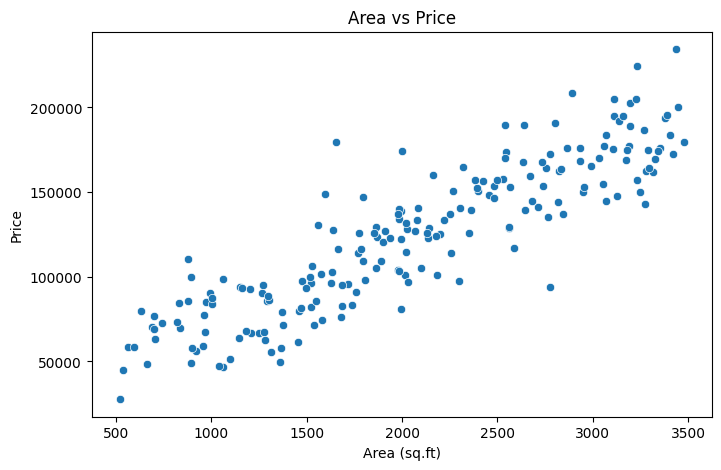

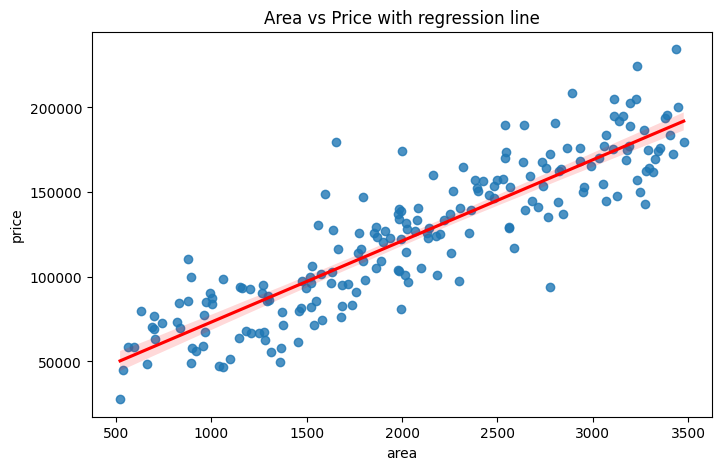

Correlation between area and price: 0.8894


In [4]:
# Cell 5: EDA - scatter plot and correlation
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x=FEATURE_COL, y=TARGET_COL)
plt.title('Area vs Price')
plt.xlabel('Area (sq.ft)')
plt.ylabel('Price')
plt.show()

# Simple regression line visualization
plt.figure(figsize=(8,5))
sns.regplot(data=df, x=FEATURE_COL, y=TARGET_COL, line_kws={"color":"red"})
plt.title('Area vs Price with regression line')
plt.show()

# Correlation
corr = df[[FEATURE_COL, TARGET_COL]].corr().iloc[0,1]
print(f"Correlation between {FEATURE_COL} and {TARGET_COL}: {corr:.4f}")

## Feature Engineering & Scaling

Prepare input feature `area` and target `price`. For single-feature linear regression we will use `area` as-is. We'll also demonstrate simple scaling (optional) — if the exam dataset has many features, select relevant columns here.

In [5]:
# Cell 6: Feature selection and optional scaling
# Select feature and target from dataframe (update names if dataset differs)
X = df[[FEATURE_COL]].values  # keep as 2D array
y = df[TARGET_COL].values     # 1D array

# Show shapes
print('X shape:', X.shape)
print('y shape:', y.shape)

# Optional scaling - linear regression does not require it, but it's shown for completeness
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print('\nFirst 5 unscaled X:\n', X[:5].ravel())
print('\nFirst 5 scaled X:\n', X_scaled[:5].ravel())

# Note: If your exam CSV has more columns, select them here, e.g.
# X = df[["area","bedrooms","age"]].values
# and update MODEL input accordingly.

X shape: (200, 1)
y shape: (200,)

First 5 unscaled X:
 [1360 1794 1630 1595 2138]

First 5 scaled X:
 [-0.86270314 -0.33156413 -0.53227104 -0.57510483  0.08943084]


## Theory: Simple Linear Regression

Simple Linear Regression fits a line y = m*x + b that best predicts the continuous target `y` (price) from a single input `x` (area). The model learns slope `m` and intercept `b` by minimizing squared errors on the training data.

## Mathematical Representation

The model equation is:

y = m * x + b

where:
- y = house price (target)
- x = area (feature)
- m = slope (weight)
- b = intercept (bias)

The model finds m and b by minimizing the mean squared error between predictions and actual values.

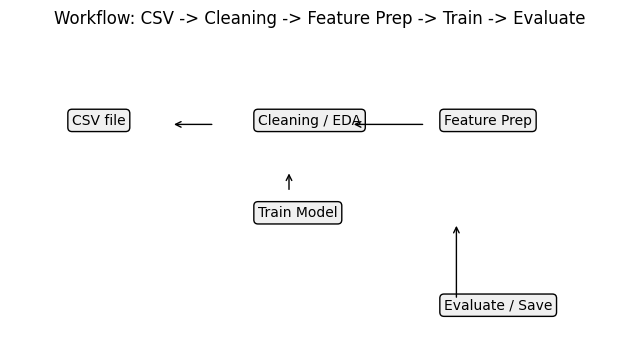

In [6]:
# Cell 7: Workflow diagram (simple) - boxes and arrows
plt.figure(figsize=(8,4))
plt.axis('off')
plt.text(0.1, 0.7, 'CSV file', bbox=dict(boxstyle='round', facecolor='#f0f0f0'))
plt.text(0.4, 0.7, 'Cleaning / EDA', bbox=dict(boxstyle='round', facecolor='#f0f0f0'))
plt.text(0.7, 0.7, 'Feature Prep', bbox=dict(boxstyle='round', facecolor='#f0f0f0'))
plt.text(0.4, 0.4, 'Train Model', bbox=dict(boxstyle='round', facecolor='#f0f0f0'))
plt.text(0.7, 0.1, 'Evaluate / Save', bbox=dict(boxstyle='round', facecolor='#f0f0f0'))
# arrows
plt.annotate('', xy=(0.26,0.7), xytext=(0.33,0.7), arrowprops=dict(arrowstyle='->'))
plt.annotate('', xy=(0.55,0.7), xytext=(0.67,0.7), arrowprops=dict(arrowstyle='->'))
plt.annotate('', xy=(0.45,0.55), xytext=(0.45,0.48), arrowprops=dict(arrowstyle='->'))
plt.annotate('', xy=(0.72,0.38), xytext=(0.72,0.13), arrowprops=dict(arrowstyle='->'))
plt.title('Workflow: CSV -> Cleaning -> Feature Prep -> Train -> Evaluate')
plt.show()

## Pseudocode

1. Load CSV into DataFrame
2. Inspect dataset (head, shape, dtypes)
3. Clean data (drop duplicates, remove invalid rows)
4. Visualize area vs price and compute correlation
5. Select `area` as input (X) and `price` as target (y)
6. Optionally scale X
7. Split into train/test
8. Train LinearRegression on train set
9. Predict on test set
10. Evaluate using MAE, MSE, RMSE, R2
11. Save trained model and scaler

In [7]:
# Cell 8: Train-test split, model training, prediction
# Split - keep random_state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Train simple linear regression
model = LinearRegression()
model.fit(X_train, y_train)

# Model parameters
slope = model.coef_[0]
intercept = model.intercept_
print(f"Learned slope (m): {slope:.4f}")
print(f"Learned intercept (b): {intercept:.2f}")

# Predict on test set
y_pred = model.predict(X_test)

# Show a few predictions vs actuals
print('\nSample predictions (first 8):')
for i in range(8):
    area_orig = scaler.inverse_transform(X_test[i].reshape(1,-1))[0,0]
    print(f"area={area_orig:.0f} -> actual={y_test[i]:.1f}, predicted={y_pred[i]:.1f}")

Learned slope (m): 38851.2709
Learned intercept (b): 123418.14

Sample predictions (first 8):
area=2562 -> actual=129343.5, predicted=147052.6
area=2891 -> actual=208359.1, predicted=162695.6
area=3058 -> actual=177449.2, predicted=170635.9
area=1683 -> actual=95349.1, predicted=105258.7
area=1460 -> actual=79764.3, predicted=94655.7
area=700 -> actual=76779.0, predicted=58520.0
area=2000 -> actual=174403.4, predicted=120331.1
area=2481 -> actual=146320.3, predicted=143201.3


Evaluation metrics:
MAE: 17050.53
MSE: 489271263.48
RMSE: 22119.48
R2 score: 0.7454


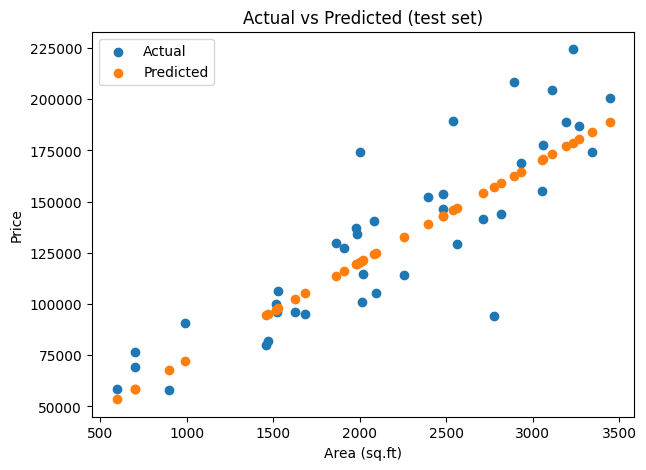

In [8]:
# Cell 9: Evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print('Evaluation metrics:')
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2 score: {r2:.4f}")

# Plot predictions vs actuals
plt.figure(figsize=(7,5))
plt.scatter(scaler.inverse_transform(X_test), y_test, label='Actual')
plt.scatter(scaler.inverse_transform(X_test), y_pred, label='Predicted')
plt.xlabel('Area (sq.ft)')
plt.ylabel('Price')
plt.legend()
plt.title('Actual vs Predicted (test set)')
plt.show()

## Expected Output

For example, if area = 1000 sq.ft and the underlying relation is price = 50*area + 20000, then expected price ≈ 50*1000 + 20000 = 70,000. The trained model's prediction should be close to this value for similar-area samples.

In [9]:
# Cell 10: Sample prediction (Expected vs Obtained)
sample_area = np.array([[1000]])
sample_area_scaled = scaler.transform(sample_area)
sample_pred = model.predict(sample_area_scaled)[0]
expected_price = 50 * 1000 + 20000
print(f"Sample area: {sample_area[0,0]} sq.ft")
print(f"Expected (approx): {expected_price:.1f}")
print(f"Model predicted: {sample_pred:.1f}")

# Obtained output summary
print('\nObtained Output Summary:')
print(f"Test R2: {r2:.4f}, RMSE: {rmse:.2f}")
if r2 > 0.8:
    print('Model performs well on synthetic data.')
else:
    print('Model performance is moderate; consider more features or cleaning for real data.')

Sample area: 1000 sq.ft
Expected (approx): 70000.0
Model predicted: 72784.1

Obtained Output Summary:
Test R2: 0.7454, RMSE: 22119.48
Model performance is moderate; consider more features or cleaning for real data.


In [10]:
# Cell 11: Save trained model and scaler to disk
MODEL_PATH = 'slr_model.joblib'
SCALER_PATH = 'scaler.joblib'
joblib.dump(model, MODEL_PATH)
joblib.dump(scaler, SCALER_PATH)
print(f"Saved model to {MODEL_PATH} and scaler to {SCALER_PATH}")

# Notes for exam: To use a different CSV, update DATA_PATH, FEATURE_COL, TARGET_COL in the first code cell.
# If the dataset has multiple features, select them in the feature engineering cell and adjust shapes accordingly.

Saved model to slr_model.joblib and scaler to scaler.joblib


## Obtained Output

This section prints the actual predictions and evaluation scores from the model (see cells above). For the synthetic CSV we created, the R2 score should be high because data follows an approximately linear relationship. For real exam data, you may need more features and stronger cleaning.